### General code

In [1]:
import torch
#check if cuda is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available. Using GPU.")
else:
    device = torch.device("cpu")
    print("CUDA is not available. Using CPU.")

CUDA is available. Using GPU.


In [2]:
import sys
sys.path.insert(0, "/home/nfm/ViT-Prisma/src")

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import vit_prisma
from vit_prisma.utils.data_utils.imagenet.imagenet_dict import IMAGENET_DICT
from vit_prisma.utils import prisma_utils

import numpy as np
import torch
from fancy_einsum import einsum
from collections import defaultdict

import plotly.graph_objs as go
import plotly.express as px

import matplotlib.colors as mcolors

from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from IPython.core.display import display, HTML


class ConvertTo3Channels:
    def __call__(self, img):
        if img.mode != 'RGB':
            return img.convert('RGB')
        return img

transform = transforms.Compose([
    ConvertTo3Channels(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

/home/nfm/prisma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nfm/prisma/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


/tmp/ipykernel_674772/3027128810.py:25: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display



In [3]:
from vit_prisma.models.base_vit import HookedViT

# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_linear_probe_real"
# model_name = "vit_base_patch16_224"
# model_name = "vit_base_patch16_clip_224.laion2b_ft_in1k"
# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_fullft"
model_name = "open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K"
model = HookedViT.from_pretrained(model_name,
                                        center_writing_weights=True,
                                        center_unembed=True,
                                        fold_ln=True,
                                        refactor_factored_attn_matrices=True,
                                        device="cuda"
                                    )

model = model.to("cuda:0")
model.cfg.device = "cuda:0"
print("Model device config:", model.cfg.device)
print("Is CUDA available?:", torch.cuda.is_available())

2026-06-01 13:21:34 INFO:root: Model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' is supported and passes tests.
2026-06-01 13:21:34 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-06-01 13:21:34 DEBUG:urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443


*****Loading model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' of type 'VISION'


2026-06-01 13:21:35 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_config.json HTTP/1.1" 307 0
2026-06-01 13:21:35 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/laion/CLIP-ViT-B-16-laion2B-s34B-b88K/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_config.json HTTP/1.1" 200 0
2026-06-01 13:21:35 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-06-01 13:21:35 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_pytorch_model.bin HTTP/1.1" 302 0
2026-06-01 13:21:37 INFO:root: visual projection shape: torch.Size([768, 512])


LayerNorm folded.
Centered weights writing to residual stream


2026-06-01 13:21:42 INFO:root: Loaded pretrained model open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K into HookedTransformer


Model device config: cuda:0
Is CUDA available?: True


In [4]:
import json
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

idx_to_wnid = {int(idx): wnid for idx, (wnid, name) in imagenet_class_index.items()}
name_to_idx = {name: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}

### Saving Head activations

In [ ]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- 1. CONFIGURATION ---
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16_newdataset'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!
LAYERS_TO_KEEP = 4 

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. LOAD CLASS NAMES ---
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

# --- 3. DATASET & DATALOADER ---
# ImageFolder automatically sorts by folder name, so 50 images per folder = perfect batches
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=transform) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Calculate how many heads we are slicing (4 layers * 12 heads = 48 heads)
num_heads_to_keep = LAYERS_TO_KEEP * model.cfg.n_heads

print(f"Starting extraction. Saving {num_heads_to_keep}x50x{model.cfg.d_model} tensors...")

# --- 4. MAIN EXTRACTION LOOP ---
for batch_imgs, batch_labels in tqdm(dataloader, total=len(dataloader)):
    
    # Get the class info from the first image in the batch
    class_idx = batch_labels[0].item()
    folder_id = dataset.classes[class_idx]
    class_name = wnid_to_name.get(folder_id, "unknown_class")
    
    batch_imgs = batch_imgs.to(model.cfg.device)

    # --- 5. SAVE TO DISK ---
    filename = f"{folder_id}_{class_name}.pt"
    save_path = os.path.join(OUTPUT_DIR, filename)

    # if os.path.exists(save_path):
    #     continue
    
    with torch.no_grad():
        # Run forward pass and cache activations for all 50 images
        _, cache = model.run_with_cache(batch_imgs)
        
        # Extract the CLS token output for ALL heads
        # Shape: [144, 50, 768] (assuming 12 layers)
        all_head_residuals = cache.stack_head_results(layer=-1, pos_slice=0)

        scaled_head_residuals = cache.apply_ln_to_stack(
            all_head_residuals, layer=-1, pos_slice=0
        )
        
        # Slice to keep only the last 4 layers (last 48 indices on the 0th dimension)
        # Shape becomes: [48, 50, 768]
        last_4_layers_residual = scaled_head_residuals[-num_heads_to_keep:, :, :]
        

    
    # Move to CPU before saving to keep VRAM clear
    torch.save(last_4_layers_residual.cpu().clone(), save_path)
    
    # Clear cache and VRAM for the next class
    del cache
    del all_head_residuals
    del last_4_layers_residual
    del scaled_head_residuals
    torch.cuda.empty_cache()

print(f"Extraction complete! Saved to {OUTPUT_DIR}")

### Labelling CLIP ViT heads with direct text attribution

In [4]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!

dataset = ImageFolder(IMAGENET_VAL_DIR) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [5]:
import os
import json
import torch
from torch import einsum

LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}


def residual_stack_to_logit_attn(centered_residual_stack, answer_residual_direction):    
    raw_dla = torch.einsum(
        "h b d, c d -> h b c",  # h=heads, b=batch, d=d_model, c=classes
        centered_residual_stack,
        answer_residual_direction,
    )
    return raw_dla 

def calculate_dla(model, text_dict, head_idx, TENSORS_DIR):
    proj_head = model.head.W_H
    target_direction = text_dict @ proj_head.T
    target_direction = target_direction.to(model.cfg.device)

    if len(head_idx) >= 12 and text_dict.shape[0]>1000:
        print("Warning: You are slicing more than 12 heads and using more than 1000 text descriptions. This may lead to very large tensors that could exceed your GPU memory. Consider reducing the number of heads or text descriptions for a more manageable tensor size.")
        return None
        
    final_tensor = torch.zeros(1000,len(head_idx), 50, len(texts)) # [ImageClass, Head, LogitClass]

    pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]
    for pth in pths:
        # Extract the WNID from the filename (e.g., 'n01440764_tench.pt' -> 'n01440764')
        wnid = pth.split('_')[0]
        
        # Find its exact 0-999 integer index
        true_class_idx = wnid_to_idx[wnid]
        
        # Load and compute
        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, weights_only=True).to(model.cfg.device) 
        
        per_head_attribution = residual_stack_to_logit_attn(per_head_residual[head_idx], target_direction)
        
        # Insert it into the EXACT right row based on its official ImageNet index
        final_tensor[true_class_idx] = per_head_attribution.cpu()

        final_tensor = final_tensor.detach().cpu()
    
    return final_tensor

def find_top_texts_topk(final_tensor, head_idx, target_idx, texts, thresh = None):
    all_heads_dict = {}
    for shibu in range(len(target_idx)):
        messi = target_idx[shibu] - head_idx[0]
        print(f"Analyzing Layer {8+head_idx[messi]//12} Head {head_idx[messi]%12}...")    
        temp = torch.clone(final_tensor[:,messi,:,:])
        if thresh is None:
            gaga = 500
            values, flat_idx = temp.reshape(-1).topk(gaga, largest=True)
        else:
            # gaga = (temp > thresh[1]).sum().item() + (temp < thresh[0]).sum().item()
            gaga = (temp > thresh[1]).sum().item()
            values, flat_idx = temp.reshape(-1).topk(gaga, largest=True)
            # values = temp[temp > thresh[1]]
            # flat_idx = torch.nonzero(temp > thresh[1]).flatten()
            # values = torch.cat((values, temp[temp < thresh[0]]))
            # flat_idx = torch.cat((flat_idx, torch.nonzero(temp < thresh[0]).flatten()))

        # unravel flat indices to 3D coords
        A, B, C = temp.shape
        i = flat_idx // (B * C)
        j = (flat_idx % (B * C)) // C
        k = flat_idx % C
        indices = torch.stack([i, j, k], dim=1)


        top_names = []
        avg_vals = {}
        for i in range(gaga):
            top_names.append(texts[indices[i][2].item()])
            avg_vals[texts[indices[i][2].item()]] = avg_vals.get(texts[indices[i][2].item()], []) + [values[i].item()]

        #sort avg_vals by mean value
        # avg_vals = {k: sum(v)/len(v) for k, v in avg_vals.items()}
        # avg_vals = dict(sorted(avg_vals.items(), key=lambda item: item[1], reverse=True))

        all_heads_dict[f"Layer {8+head_idx[messi]//12} Head {head_idx[messi]%12}"] = avg_vals


        from collections import Counter
        name_counts = Counter(top_names)
        # print(name_counts.most_common(20))
        # print(list(avg_vals.items())[:20])
        for name, count in name_counts.most_common(20):
            print(f"{name}: {count} : {sum(avg_vals[name])/len(avg_vals[name]):.3f}", end="||")
        print("\n" + "-"*50)

        return all_heads_dict

### Plots

In [6]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

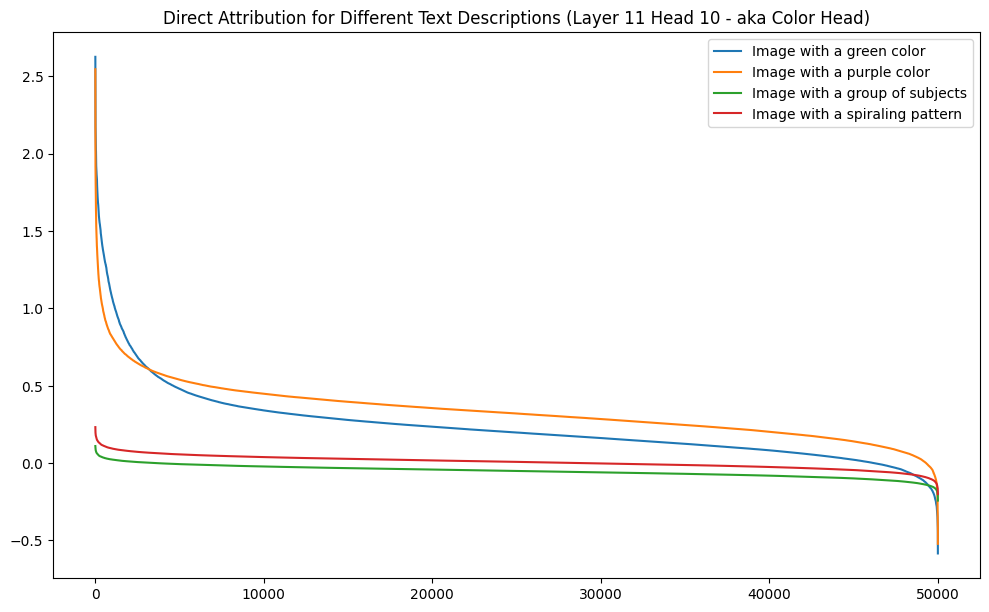

In [7]:
import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(10, 6), dpi=100)  # higher dpi for display

for txt in [
    "Image with a green color",
    "Image with a purple color",
    "Image with a group of subjects",
    "Image with a spiraling pattern"
]:
    idx = texts.index(txt)
    temp = final_tensor[:, 1, :, idx].flatten()

    # sort temp
    temp = temp[torch.argsort(temp, descending=True)]

    plt.plot(temp.numpy(), label=txt)

plt.legend()
plt.tight_layout()
plt.title("Direct Attribution for Different Text Descriptions (Layer 11 Head 10 - aka Color Head)")

# Save high-resolution image
# plt.savefig("high_res_plot.png", dpi=300, bbox_inches="tight")

plt.show()

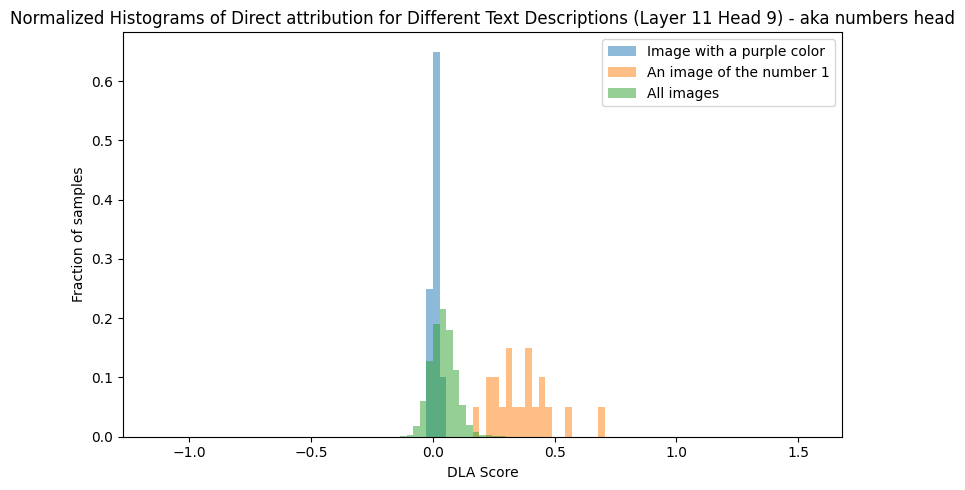

In [15]:
import numpy as np
import matplotlib.pyplot as plt

idx_head = 0
# build 1D numpy arrays for each case
txt1 = "Image with a purple color"
idx = texts.index(txt1); img_inds = indices_dict[idx][:20]
a1 = final_tensor[:, idx_head, :, idx].flatten()[img_inds].numpy()

# txt2 = "A photo with the letter A"
txt2 = "An image of the number 1"
idx = texts.index(txt2); img_inds = indices_dict[idx][:20]
a2 = final_tensor[:, idx_head, :, idx].flatten()[img_inds].numpy()

# all images
a3 = final_tensor[:, idx_head, :, :].flatten().numpy()

arrays = [a1, a2, a3]
labels = [txt1, txt2, "All images"]

# common bins
data_min = min(arr.min() for arr in arrays)
data_max = max(arr.max() for arr in arrays)
bins = np.linspace(data_min, data_max, 100)

plt.figure(figsize=(8,5))
for arr, label in zip(arrays, labels):
    weights = np.ones_like(arr) / arr.size            # normalizes counts by sample count
    plt.hist(arr, bins=bins, weights=weights, alpha=0.5, label=label)

plt.title("Normalized histograms (counts / n_samples)")
plt.xlabel("DLA Score")
plt.ylabel("Fraction of samples")
plt.title("Normalized Histograms of Direct attribution for Different Text Descriptions (Layer 11 Head 9) - aka numbers head")
plt.legend()
plt.tight_layout()
plt.show()

### Entropy and Predicting fate of heads

In [6]:
import psutil

import gc
gc.collect()

def ram_info():
    mem = psutil.virtual_memory()
    total = mem.total / (1024 ** 3)
    available = mem.available / (1024 ** 3)
    used = mem.used / (1024 ** 3)
    percent = mem.percent

    print(f"Total RAM: {total:.2f} GB")
    print(f"Available RAM: {available:.2f} GB")
    print(f"Used RAM: {used:.2f} GB ({percent}%)")

ram_info()

Total RAM: 44.12 GB
Available RAM: 19.31 GB
Used RAM: 24.81 GB (56.2%)


In [7]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

In [ ]:
# save_dir = "/home/nfm/ViT-Prisma/mynotebooks/files"

# os.makedirs(save_dir, exist_ok=True)
# pth = os.path.join(save_dir, "CLIP_DTA_imagenet_all_heads_safe.pt")
# # convert final_tensor to bf16 to save space
# DTA_imagent = DTA_imagent.to(torch.bfloat16)
# torch.save(DTA_imagent, pth)

In [8]:
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_vitpatch16'
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clip_linear_probe_real'
# ggg = "Linear Probe CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
# ggg = "TIMM Full FT CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_myfullft'
# ggg = "My Full FT CLIP"
TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
ggg = "Original Clip"

text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt")
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]
for_print = "With 3500 general text descriptions, model:" + ggg

# text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict_imagenet.pt")
# text_dict = text_dict.to("cuda")
# texts = [idx_to_name[i] for i in range(1000)]
# for_print = "With 1000 ImageNet class name descriptions, model:" + ggg

print(for_print)

# DTA_imagent = calculate_dla(model, text_dict, head_idx=list(range(48)), TENSORS_DIR=TENSORS_DIR)


With 3500 general text descriptions, model:Original Clip


In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

def find_elbows(temp, plot_elbows=False, sigma = 500, elbows_to_find=2):
    temp_sorted = torch.sort(temp).values
    num_plot = 1_000_000
    idx = torch.arange(
        num_plot,
        device=temp_sorted.device
    ) * (temp_sorted.shape[0] - 1) // (num_plot - 1)
    y = temp_sorted[idx].float().cpu().numpy() if temp_sorted.shape[0] > num_plot else temp_sorted.float().cpu().numpy()
    x = np.linspace(0, 1, len(y))
    y_smooth = gaussian_filter1d(y, sigma=sigma)


    dy = np.gradient(y_smooth)
    d2y = np.gradient(dy)
    curvature = np.abs(d2y)
    peaks, _ = find_peaks(
        curvature,
        distance=len(curvature)//5,
        prominence=np.max(curvature) * 0.1
    )

    top2 = peaks[np.argsort(curvature[peaks])[-elbows_to_find:]]
    top2 = np.sort(top2)

    low_thresh = y[top2][0].item()
    high_thresh = y[top2][1].item() if len(top2) > 1 else None

    if plot_elbows:
        plt.figure(figsize=(12, 6))
        plt.plot(y, linewidth=1)
        for i, p in enumerate(top2):
            plt.axvline(p, color='red', linestyle='--')
            plt.scatter(
                p,
                y[p],
                color='red',
                s=100,
                label=f'Elbow {i+1}' if i == 0 else None
            )

        plt.legend()
        plt.title("Sorted Values with Detected Elbows")
        plt.show()
    print("Elbow indices:", top2)
    print("Elbow values:", y[top2])

    return low_thresh, high_thresh


def calculate_weighted_effective_dimension(activations, weights=None, weight_transform="log"):
    """    
    Args:
        activations: torch.Tensor of shape (N, D). e.g., (800, 512) for text embeds.
        weights: torch.Tensor of shape (N, 1) or (N,). These are your counts.
    """
    if weights is None:
        weights = torch.ones(activations.shape[0], 1, device=activations.device)
    if weights.dim() == 1:
        weights = weights.unsqueeze(1)
        
    if weight_transform == "log":
        w = torch.log1p(weights)
    elif weight_transform == "sqrt":
        w = torch.sqrt(weights)
    else:
        w = weights.clone()
    w = w / torch.sum(w)
    weighted_mean = torch.sum(activations * w, dim=0, keepdim=True)
    centered_acts = activations - weighted_mean
    weighted_cov = (centered_acts * w).T @ centered_acts
    
    eigenvalues = torch.linalg.eigvalsh(weighted_cov)
    eigenvalues = torch.clamp(eigenvalues, min=0.0)
    
    sum_eig = torch.sum(eigenvalues)
    sum_sq_eig = torch.sum(eigenvalues ** 2)
    
    if sum_sq_eig == 0:
        return 0.0
        
    effective_dim = (sum_eig ** 2) / sum_sq_eig
    return effective_dim.item()

import math
import torch


def calculate_weighted_effective_dimension(
    activations,
    weights=None,
    weight_transform="log",
    return_basis=False,
):
    N, D = activations.shape

    if weights is None:
        weights = torch.ones(N, 1, device=activations.device)

    if weights.dim() == 1:
        weights = weights.unsqueeze(1)

    # transform weights
    if weight_transform == "log":
        w = torch.log1p(weights)
    elif weight_transform == "sqrt":
        w = torch.sqrt(weights)
    else:
        w = weights.clone()

    # normalize
    w = w / w.sum()

    # weighted mean
    weighted_mean = (activations * w).sum(dim=0, keepdim=True)

    # center
    centered = activations - weighted_mean

    # weighted covariance
    cov = (centered * w).T @ centered

    # eigendecomposition
    eigenvalues, eigenvectors = torch.linalg.eigh(cov)

    # ascending -> descending
    idx = torch.argsort(eigenvalues, descending=True)

    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    eigenvalues = torch.clamp(eigenvalues, min=0)

    # participation ratio
    sum_eig = eigenvalues.sum()
    sum_sq_eig = (eigenvalues ** 2).sum()

    eps = 1e-12
    if sum_sq_eig < eps:
        effective_dim = 0.0
    else:
        effective_dim = ((sum_eig ** 2) / sum_sq_eig).item()

    if not return_basis:
        return effective_dim

    n_basis = math.ceil(effective_dim)

    top_eigenvectors = eigenvectors[:, :n_basis]
    top_eigenvalues = eigenvalues[:n_basis]

    explained_variance_ratio = (
        top_eigenvalues.sum() / eigenvalues.sum()
    ).item()

    return {
        "effective_dim": effective_dim,
        "n_basis": n_basis,
        "basis": top_eigenvectors,
        "eigenvalues": top_eigenvalues,
        "explained_variance_ratio": explained_variance_ratio,
        "all_eigenvalues": eigenvalues,
    }

In [13]:
import os
import torch

def get_thresholded_activations(dta_matrix, original_head_idx, target_heads, TENSORS_DIR, wnid_to_idx, low_threshold, high_threshold, consider_neg=False):
    """
    Filters and stacks activations for a specific subset of heads based on DTA thresholds.
    """
    # 1. Isolate the target heads in the DTA matrix
    rel_indices = [original_head_idx.index(h) for h in target_heads]
    dta_subset = dta_matrix[:, rel_indices, :, :]
    
    # 2. Apply the head-specific thresholds to the subset
    high_t = torch.tensor(high_threshold, device=dta_matrix.device).view(1, -1, 1, 1)
    low_t = torch.tensor(low_threshold, device=dta_matrix.device).view(1, -1, 1, 1)
    
    if consider_neg:
        condition = (dta_subset > high_t) | (dta_subset < low_t)
    else:
        condition = (dta_subset > high_t)
    mask = condition.any(dim=-1) # Shape: (1000, len(target_heads), 50)
    
    filtered_activations = []
    metadata = []
    
    pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]
    
    for pth in pths:
        wnid = pth.split('_')[0]
        if wnid not in wnid_to_idx:
            continue
            
        true_class_idx = wnid_to_idx[wnid]
        class_mask = mask[true_class_idx] # Shape: (len(target_heads), 50)
        
        # Skip loading if no images in this class met the threshold for the target heads
        if not class_mask.any():
            continue
            
        # Load residual file
        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, map_location='cpu', weights_only=True)
        
        # EXTRACT ONLY THE TARGET HEADS from the saved tensor
        subset_residual = per_head_residual[target_heads] 
        
        # Apply the mask to extract the thresholded activations
        matching_acts = subset_residual[class_mask] 
        filtered_activations.append(matching_acts)
        
        # Store metadata
        indices = class_mask.nonzero(as_tuple=False) 
        for idx in indices:
            rel_head_in_subset = idx[0].item()
            img_id = idx[1].item()
            
            metadata.append({
                'class_idx': true_class_idx,
                'wnid': wnid,
                'head_idx': target_heads[rel_head_in_subset], # Maps back to the exact model head
                'image_idx': img_id
            })
            
    if not filtered_activations:
        print("No activations met the threshold criteria for the target heads.")
        return None, []
        
    final_stacked_acts = torch.cat(filtered_activations, dim=0)
    
    return final_stacked_acts, metadata

In [30]:
pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]

for head_idx in range(36, 48):
    head_act_norms = []
    act_cache = []

    for pth in pths:
        wnid = pth.split('_')[0]
        if wnid not in wnid_to_idx:
            continue
            
        true_class_idx = wnid_to_idx[wnid]

        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, map_location='cpu', weights_only=True)
        
        head_act = per_head_residual[head_idx]
        head_act_norms.append(head_act.norm(dim=-1).cpu())

        # cache the top 5 activations by norm
        top5_indices = torch.topk(head_act.norm(dim=-1), k=5, largest=True).indices
        act_cache.append(head_act[top5_indices].cpu())

    head_act_norms = torch.cat(head_act_norms, dim=0)
    act_cache = torch.cat(act_cache, dim=0)

    pr_act_cache = calculate_weighted_effective_dimension(act_cache, weights=None, weight_transform="log")
    print(f"Prisma Effective Dimension for Layer{8+head_idx//12} head {head_idx%12}:", pr_act_cache)

Prisma Effective Dimension for Layer11 head 0: 16.117387771606445
Prisma Effective Dimension for Layer11 head 1: 40.44307327270508
Prisma Effective Dimension for Layer11 head 2: 38.878238677978516
Prisma Effective Dimension for Layer11 head 3: 31.204763412475586
Prisma Effective Dimension for Layer11 head 4: 14.501023292541504
Prisma Effective Dimension for Layer11 head 5: 23.666223526000977
Prisma Effective Dimension for Layer11 head 6: 23.12200355529785
Prisma Effective Dimension for Layer11 head 7: 35.06602478027344
Prisma Effective Dimension for Layer11 head 8: 35.62123107910156
Prisma Effective Dimension for Layer11 head 9: 22.733909606933594
Prisma Effective Dimension for Layer11 head 10: 20.502086639404297
Prisma Effective Dimension for Layer11 head 11: 37.83204650878906


In [29]:
# head_act_norms.shape, act_cache.shape

pr_act_cache = calculate_weighted_effective_dimension(act_cache, weights=None, weight_transform="log")
print("Prisma Effective Dimension:", pr_act_cache)

Prisma Effective Dimension: 37.83204650878906


In [26]:
# len(texts)
# color related texts
color_texts = []
for txt in texts:
    if "color" in txt or "hue" in txt or "tones" in txt:
        color_texts.append(txt)

print(f"Found {len(color_texts)} color-related texts.")

# now sample len(color_texts) texts from texts
random_indices = torch.randperm(len(texts))[:len(color_texts)]
sampled_texts = [texts[i] for i in random_indices]

color_embeddings = text_dict[[texts.index(txt) for txt in color_texts]]
random_embeddings = text_dict[[texts.index(txt) for txt in sampled_texts]]

color_pr = calculate_weighted_effective_dimension(color_embeddings, weights=None, weight_transform="log")
random_pr = calculate_weighted_effective_dimension(random_embeddings, weights=None, weight_transform="log")

print(f"Prisma Effective Dimension for color-related texts: {color_pr:.2f}")
print(f"Prisma Effective Dimension for random texts: {random_pr:.2f}")

Found 105 color-related texts.
Prisma Effective Dimension for color-related texts: 18.87
Prisma Effective Dimension for random texts: 45.61


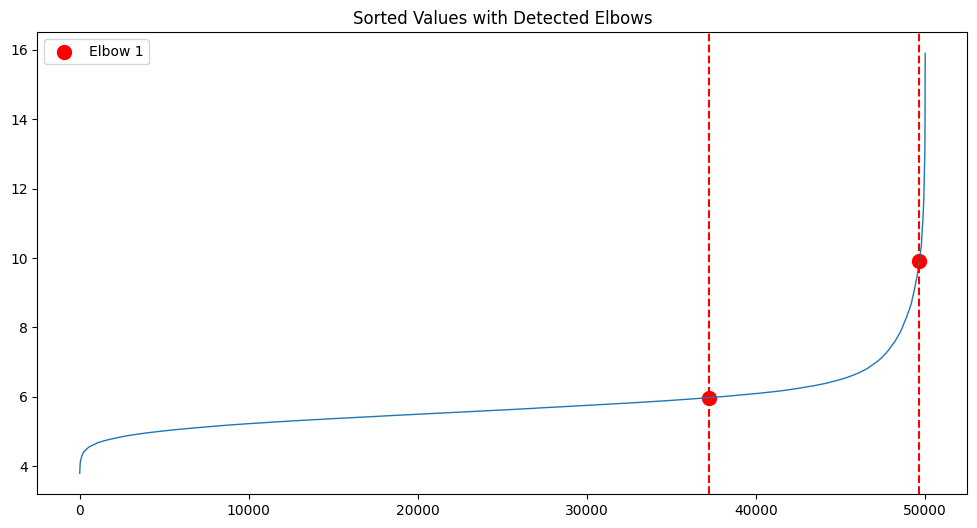

Elbow indices: [37190 49643]
Elbow values: [5.9711657 9.902286 ]
Number of activations above high threshold: 356
Number of activations below low threshold: 37190


In [92]:
# head_act_norms.mean(), head_act_norms.std(), head_act_norms.max(), head_act_norms.min()
# sort and plot it, also its histogram
# sorted_norms, _ = torch.sort(head_act_norms)
# plt.plot(sorted_norms.numpy())

# plt.figure(figsize=(8,5))
# plt.hist(head_act_norms.numpy(), bins=100, density=True, alpha=0.7)
# plt.title("Histogram of Activation Norms for Layer 11 Head 10 (Color Head)")
# plt.xlabel("Activation Norm")
# plt.ylabel("Density")
# plt.show()

th1, th2 = find_elbows(head_act_norms, plot_elbows=True, sigma=5000)
# print number of activations above high threshold and below low threshold
num_above_high = (head_act_norms > th2).sum().item()
print(f"Number of activations above high threshold: {num_above_high}")

num_below_low = (head_act_norms < th1).sum().item()
print(f"Number of activations below low threshold: {num_below_low}")

In [15]:
DTA_imagent = torch.load("/home/nfm/ViT-Prisma/mynotebooks/files/CLIP_DTA_36_48.pt")
real_heads = list(range(36,48))

In [16]:
text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt")

head = 47
head_adj = head - 36
temp = torch.clone(DTA_imagent[:, head_adj, :, :]).flatten()
low_thresh, high_thresh = find_elbows(temp, plot_elbows=False)

top_texts_dict = find_top_texts_topk(DTA_imagent, head_idx=real_heads, target_idx=[head], texts=texts, thresh=(low_thresh, high_thresh))

stacked_text_embeds = []
weights = []
for head_name, top_texts in top_texts_dict.items():
    for text, score_list in top_texts.items():
        text_idx = texts.index(text)
        text_embed = text_dict[text_idx]
        stacked_text_embeds.append(text_embed)
        weights.append(len(score_list))


stacked_text_embeds = torch.stack(stacked_text_embeds)
weights = torch.tensor(weights, dtype=torch.float32, device=stacked_text_embeds.device).unsqueeze(1)

stacked_activations, metadata = get_thresholded_activations(
    DTA_imagent,
    original_head_idx=real_heads,
    target_heads=[head],
    TENSORS_DIR=TENSORS_DIR,
    wnid_to_idx=wnid_to_idx,
    low_threshold=[low_thresh],
    high_threshold=[high_thresh])
        

Elbow indices: [    24 999965]
Elbow values: [-0.39453125  0.43945312]
Analyzing Layer 11 Head 11...
A photo with the letter J: 177 : 0.585||A photo with the letter K: 151 : 0.602||A photo with the letter Y: 147 : 0.552||A photo with the letter L: 134 : 0.571||A photo with the letter E: 123 : 0.568||A photo with the letter V: 114 : 0.568||A zephyr: 111 : 0.582||A photo with the letter W: 105 : 0.569||A photo with the letter P: 103 : 0.556||A photo with the letter M: 102 : 0.551||A photo with the letter A: 101 : 0.542||A photo with the letter R: 100 : 0.599||A photo with the letter N: 98 : 0.583||A photo with the letter F: 98 : 0.565||A photo with the letter H: 96 : 0.585||Vivid cultural representation: 96 : 0.545||A photo with the letter C: 95 : 0.561||A photo with the letter U: 94 : 0.527||A photo with the letter Z: 87 : 0.580||A photo with the letter G: 83 : 0.560||
--------------------------------------------------


In [17]:
# weights.shape
# plt.hist(weights.cpu().numpy(), bins=50)

In [18]:
output_dict = calculate_weighted_effective_dimension(stacked_activations, weights=None, weight_transform="log", return_basis=True)

In [ ]:
# output_dict['effective_dim'], output_dict['explained_variance_ratio'], output_dict['n_basis']
# output_dict['basis'].shape
P = model.head.W_H
basis_projected = output_dict['basis'].to(P.device).T @ P
basis_projected.shape

cosine_similarities = torch.nn.functional.cosine_similarity(
    basis_projected[:, None, :],  # Shape: (n_basis, 1, d_model)
    text_dict[None, :, :],       # Shape: (1, num_texts, d_model)
    dim=-1
)

top_k = 10
top_k_indices = torch.topk(cosine_similarities, k=top_k, dim=1).indices
for i in range(basis_projected.shape[0]):
    print(f"Basis Vector {i+1}:")
    for idx in top_k_indices[i]:
        text_idx = idx.item()
        print(f"  {texts[text_idx]} (Cosine Similarity: {cosine_similarities[i, text_idx].item():.4f})")
    print("-" * 50)

Basis Vector 1:
  An image of Fiji (Cosine Similarity: 0.1087)
  Fading memories (Cosine Similarity: 0.0967)
  Frozen memories (Cosine Similarity: 0.0910)
  Futuristic-edge robotic innovation (Cosine Similarity: 0.0752)
  Ephemeral moment (Cosine Similarity: 0.0744)
  Picture taken in Fiji (Cosine Similarity: 0.0739)
  Enchanting  fantasy realm (Cosine Similarity: 0.0737)
  Ethereal moments (Cosine Similarity: 0.0726)
  Precise scientific equipment (Cosine Similarity: 0.0724)
  Playful narratives (Cosine Similarity: 0.0708)
--------------------------------------------------
Basis Vector 2:
  A photo with the letter C (Cosine Similarity: 0.1511)
  A photo with the letter G (Cosine Similarity: 0.1317)
  emotional candid gaze (Cosine Similarity: 0.0875)
  An image of cheeks (Cosine Similarity: 0.0865)
  Loose brushwork (Cosine Similarity: 0.0822)
  A cheap object (Cosine Similarity: 0.0819)
  A cobweb (Cosine Similarity: 0.0809)
  Evocative candid gaze (Cosine Similarity: 0.0807)
  a phot

In [57]:
pr_acts = calculate_weighted_effective_dimension(stacked_activations, weights=None, weight_transform="log")
pt_txt_embeds = calculate_weighted_effective_dimension(stacked_text_embeds, weights=None, weight_transform="bbb")

print(f"Effective Dimension of Activations: {pr_acts:.2f} out of {stacked_activations.shape[1]}")
print(f"Effective Dimension of Text Embeddings: {pt_txt_embeds:.2f} out of {stacked_text_embeds.shape[1]}")

Effective Dimension of Activations: 38.86 out of 768
Effective Dimension of Text Embeddings: 61.91 out of 512


In [58]:
for head in real_heads:
    head_adj = head - real_heads[0]
    temp = torch.clone(DTA_imagent[:, head_adj, :, :]).flatten()
    low_thresh, high_thresh = find_elbows(temp, plot_elbows=False)

    stacked_activations, metadata = get_thresholded_activations(
        DTA_imagent,
        original_head_idx=real_heads,
        target_heads=[head],
        TENSORS_DIR=TENSORS_DIR,
        wnid_to_idx=wnid_to_idx,
        low_threshold=[low_thresh],
        high_threshold=[high_thresh])
    
    top_texts_dict = find_top_texts_topk(DTA_imagent, head_idx=real_heads, target_idx=[head], texts=texts, thresh=(low_thresh, high_thresh))
    
    stacked_text_embeds = []
    weights = []
    for head_name, top_texts in top_texts_dict.items():
        for text, score_list in top_texts.items():
            text_idx = texts.index(text)
            text_embed = text_dict[text_idx]
            stacked_text_embeds.append(text_embed)
            weights.append(len(score_list))


    stacked_text_embeds = torch.stack(stacked_text_embeds)
    weights = torch.tensor(weights, dtype=torch.float32, device=stacked_text_embeds.device).unsqueeze(1)

    pr_acts = calculate_weighted_effective_dimension(stacked_activations, weights=None, weight_transform="log")
    pr_txt = calculate_weighted_effective_dimension(stacked_text_embeds, weights, weight_transform="log")

    print(f"Head {head}: Effective Dimension of Activations: {pr_acts:.2f} out of {stacked_activations.shape[1]}")
    print(f"Head {head}: Effective Dimension of Top Text Embeddings: {pr_txt:.2f} out of {stacked_text_embeds.shape[1]}")
    
    # ed = calculate_effective_dimension(stacked_activations)
    # print(f"Head {head}: Effective Dimension: {ed:.2f} out of 768")

Elbow indices: [    36 999981]
Elbow values: [-0.375     1.046875]
Analyzing Layer 11 Head 0...
Photo taken in Beijing, China: 161 : 1.183||Photo taken in Seoul, South Korea: 124 : 1.161||Picture taken in Laos: 113 : 1.203||a picture of taiwan: 111 : 1.149||A picture of Taiwan: 111 : 1.149||Picture taken in Hungary: 108 : 1.173||Image taken in South Korea: 91 : 1.149||Picture taken in China: 87 : 1.171||Picture taken in Bavaria, Germany: 78 : 1.220||Picture taken in Vietnam: 76 : 1.154||Photo taken in Bangkok, Thailand: 73 : 1.198||Picture taken in South Korea: 71 : 1.145||Image taken in Thailand: 62 : 1.198||Image taken in the Thai beaches: 49 : 1.210||Photo taken in Nepal: 47 : 1.122||A picture of South Korea: 44 : 1.153||Photo taken in Kyoto: 43 : 1.158||Image taken in the Thai temples: 41 : 1.190||Picture taken in Thailand: 40 : 1.196||Photo taken in the Italian coastal towns: 40 : 1.196||
--------------------------------------------------
Head 36: Effective Dimension of Activation

In [35]:
import re

def extract_effective_dimensions(text):
    results = {}

    # Match each analysis block
    pattern = re.compile(
        r"Analyzing Layer\s+(\d+)\s+Head\s+(\d+)\.\.\."
        r".*?"
        r"Head\s+\d+:\s+Effective Dimension of Activations:\s+([\d.]+)"
        r".*?"
        r"Head\s+\d+:\s+Effective Dimension of Top Text Embeddings:\s+([\d.]+)",
        re.DOTALL
    )

    for match in pattern.finditer(text):
        layer = int(match.group(1))
        head = int(match.group(2))
        activation_dim = float(match.group(3))
        text_dim = float(match.group(4))

        key = f"layer_{layer}_head_{head}"

        results[key] = {
            "effective_dimension_activation": activation_dim,
            "effective_dimension_text_embedding": text_dim
        }

    return results


# Example usage
with open("your_log.txt", "r", encoding="utf-8") as f:
    log_text = f.read()

dims_dict = extract_effective_dimensions(log_text)

In [36]:
for head, metrics in dims_dict.items():
    print(head, metrics)

layer_11_head_0 {'effective_dimension_activation': 10.24, 'effective_dimension_text_embedding': 24.85}
layer_11_head_1 {'effective_dimension_activation': 37.3, 'effective_dimension_text_embedding': 56.32}
layer_11_head_2 {'effective_dimension_activation': 39.61, 'effective_dimension_text_embedding': 72.28}
layer_11_head_3 {'effective_dimension_activation': 21.01, 'effective_dimension_text_embedding': 39.6}
layer_11_head_4 {'effective_dimension_activation': 11.92, 'effective_dimension_text_embedding': 12.2}
layer_11_head_5 {'effective_dimension_activation': 11.85, 'effective_dimension_text_embedding': 16.46}
layer_11_head_6 {'effective_dimension_activation': 9.15, 'effective_dimension_text_embedding': 14.56}
layer_11_head_7 {'effective_dimension_activation': 23.38, 'effective_dimension_text_embedding': 22.44}
layer_11_head_8 {'effective_dimension_activation': 17.12, 'effective_dimension_text_embedding': 21.67}
layer_11_head_9 {'effective_dimension_activation': 18.34, 'effective_dimensio

In [39]:
# sort the dictionary by activation effective dimension
sorted_dims = dict(sorted(dims_dict.items(), key=lambda item: item[1]["effective_dimension_activation"], reverse=True))
for head, metrics in sorted_dims.items():
    print(head, metrics)

print("*"*50)

sorted_dims = dict(sorted(dims_dict.items(), key=lambda item: item[1]["effective_dimension_text_embedding"], reverse=True))
for head, metrics in sorted_dims.items():
    print(head, metrics)

layer_11_head_2 {'effective_dimension_activation': 39.61, 'effective_dimension_text_embedding': 72.28}
layer_11_head_11 {'effective_dimension_activation': 38.86, 'effective_dimension_text_embedding': 40.85}
layer_11_head_1 {'effective_dimension_activation': 37.3, 'effective_dimension_text_embedding': 56.32}
layer_11_head_7 {'effective_dimension_activation': 23.38, 'effective_dimension_text_embedding': 22.44}
layer_11_head_3 {'effective_dimension_activation': 21.01, 'effective_dimension_text_embedding': 39.6}
layer_11_head_9 {'effective_dimension_activation': 18.34, 'effective_dimension_text_embedding': 40.41}
layer_11_head_8 {'effective_dimension_activation': 17.12, 'effective_dimension_text_embedding': 21.67}
layer_11_head_4 {'effective_dimension_activation': 11.92, 'effective_dimension_text_embedding': 12.2}
layer_11_head_5 {'effective_dimension_activation': 11.85, 'effective_dimension_text_embedding': 16.46}
layer_11_head_10 {'effective_dimension_activation': 11.47, 'effective_dimen

 Effective Dimension for Layer11 head 0: 16.117387771606445
 Effective Dimension for Layer11 head 1: 40.44307327270508
 Effective Dimension for Layer11 head 2: 38.878238677978516
 Effective Dimension for Layer11 head 3: 31.204763412475586
 Effective Dimension for Layer11 head 4: 14.501023292541504
 Effective Dimension for Layer11 head 5: 23.666223526000977
 Effective Dimension for Layer11 head 6: 23.12200355529785
 Effective Dimension for Layer11 head 7: 35.06602478027344
 Effective Dimension for Layer11 head 8: 35.62123107910156
 Effective Dimension for Layer11 head 9: 22.733909606933594
 Effective Dimension for Layer11 head 10: 20.502086639404297
 Effective Dimension for Layer11 head 11: 37.83204650878906